# Topics in SYNERGY+

OpenAlex classifies every work into a four-level **topic hierarchy** — Domain →
Field → Subfield → Topic.
This notebook profiles how that classification distributes across SYNERGY+:

- What subject domains and fields make up the corpus?
- What does each systematic review's dataset cluster around, and does that shift
  between the records it searched and the records it actually included?
- Does topical area correlate with how selective a review is?
- What are the most common granular topics overall, and among included records?

Topic fields (`primary_topic_domain`, `primary_topic_field`, `primary_topic_name`)
are only present in the **`synergy_plus_extended`** release, not the lighter
`synergy_plus` CSVs — so this notebook reads from `data/synergy_plus_extended`.
It also draws on `data/synergy_plus_extended/metadata/review_metadata.csv` for
review-level context (review type) alongside the per-record topic data.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

DATA_DIR = Path("..", "..", "..", "data", "synergy_plus_extended")
METADATA_PATH = DATA_DIR / "metadata" / "review_metadata.csv"

# Palette: one accent hue for magnitude comparisons, a fixed-order categorical
# set for identity comparisons (topic domain), muted tones for chrome.
BLUE = "#2a78d6"
ORANGE = "#eb6834"
GRAY = "#898781"
CATEGORICAL = [
    "#2a78d6",
    "#eb6834",
    "#1baf7a",
    "#eda100",
    "#e87ba4",
    "#008300",
    "#4a3aa7",
]
GRID = "#e1e0d9"
INK = "#0b0b0b"
SECONDARY_INK = "#52514e"

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": GRID,
        "axes.labelcolor": SECONDARY_INK,
        "text.color": INK,
        "xtick.color": SECONDARY_INK,
        "ytick.color": SECONDARY_INK,
        "axes.grid": False,
        "axes.axisbelow": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
    }
)

## Loading the data

Each review's CSV in `synergy_plus_extended` carries a lot of columns we don't need here (abstracts, author lists, MeSH terms, ...). We only load the topic and label columns to keep this fast, then load the review-level metadata separately.

In [2]:
topic_cols = {
    "openalex_id",
    "label_included",
    "label_abstract_included",
    "primary_topic_domain",
    "primary_topic_field",
    "primary_topic_name",
}

frames = []
for f in sorted(DATA_DIR.glob("*.csv")):
    df = pd.read_csv(f, usecols=lambda c: c in topic_cols)
    df["dataset_id"] = f.stem
    frames.append(df)

records = pd.concat(frames, ignore_index=True)
reviews = pd.read_csv(METADATA_PATH).set_index("key")

records.head()

,openalex_id,primary_topic_name,primary_topic_field,primary_topic_domain,label_included,label_abstract_included,dataset_id
0,https://openalex.org/w3028783161,Software System Performance and Reliability,Computer Science,Physical Sciences,1,1.0,Abgaz_2023
1,https://openalex.org/w3163266571,Software System Performance and Reliability,Computer Science,Physical Sciences,0,0.0,Abgaz_2023
2,https://openalex.org/w3068636631,Software System Performance and Reliability,Computer Science,Physical Sciences,0,0.0,Abgaz_2023
3,https://openalex.org/w2908689186,Software System Performance and Reliability,Computer Science,Physical Sciences,0,0.0,Abgaz_2023
4,https://openalex.org/w4297063250,Software System Performance and Reliability,Computer Science,Physical Sciences,0,0.0,Abgaz_2023


## Topic coverage

In [3]:
n_records = len(records)
n_datasets = records["dataset_id"].nunique()
has_topic = records["primary_topic_field"].notna().mean() * 100

display(
    Markdown(
        f"**{has_topic:.1f}%** of {n_records:,} records across {n_datasets} datasets have a primary topic "
        f"assigned, spanning **{records['primary_topic_domain'].nunique()} domains**, "
        f"**{records['primary_topic_field'].nunique()} fields**, and "
        f"**{records['primary_topic_name'].nunique():,} granular topics**."
    )
)

**99.6%** of 168,969 records across 114 datasets have a primary topic assigned, spanning **4 domains**, **26 fields**, and **3,276 granular topics**.

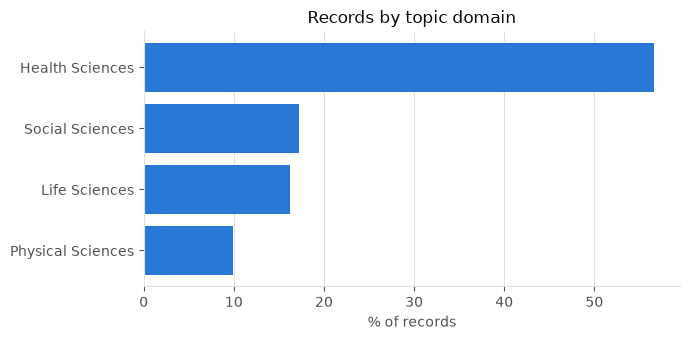

In [4]:
domain_share = (
    records["primary_topic_domain"].value_counts(normalize=True).mul(100).sort_values()
)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(domain_share.index, domain_share.values, color=BLUE)
ax.grid(axis="x")
ax.set_xlabel("% of records")
ax.set_title("Records by topic domain")
fig.tight_layout()
plt.show()

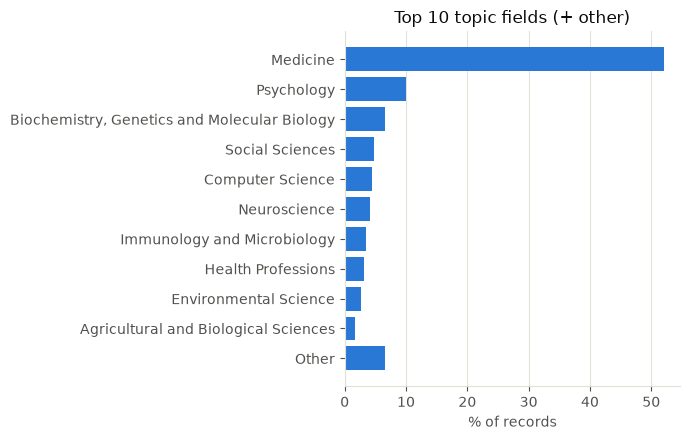

In [5]:
field_counts = records["primary_topic_field"].value_counts()
top_fields = field_counts.head(10)
other_fields = field_counts.iloc[10:].sum()
if other_fields:
    top_fields = pd.concat([top_fields, pd.Series({"Other": other_fields})])
top_fields_pct = (top_fields / n_records * 100).iloc[::-1]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(top_fields_pct.index, top_fields_pct.values, color=BLUE)
ax.grid(axis="x")
ax.set_xlabel("% of records")
ax.set_title("Top 10 topic fields (+ other)")
fig.tight_layout()
plt.show()

## What is each dataset about?

For each dataset, we take the most common ("dominant") topic field among its records, and pair it with the review type from the metadata for context.

In [6]:
def mode_or_none(s):
    m = s.mode()
    return m.iat[0] if not m.empty else None


dominant_field = records.groupby("dataset_id")["primary_topic_field"].agg(mode_or_none)
dominant_domain = records.groupby("dataset_id")["primary_topic_domain"].agg(
    mode_or_none
)

dataset_topics = pd.DataFrame(
    {
        "domain": dominant_domain,
        "dominant_field": dominant_field,
        "review_type": reviews["review_type"],
    }
).sort_values(["domain", "dominant_field"])

dataset_topics

,domain,dominant_field,review_type
Eggmann_2023,Health Sciences,Dentistry,Systematic review
Brons_2024,Health Sciences,Health Professions,Scoping review
Aouad_2024,Health Sciences,Medicine,Systematic literature review
Attai_2022,Health Sciences,Medicine,Systematic review
Bakker-Jacobs_2022,Health Sciences,Medicine,Systematic scoping review
...,...,...,...
Oliveira_2021,Social Sciences,Social Sciences,Systematic review and meta-analysis
Taschner_2024,Social Sciences,Social Sciences,Systematic review and meta-analysis
Verdugo-Castro_2022,Social Sciences,Social Sciences,Systematic literature review
Wijnen_2024,Social Sciences,Social Sciences,Systematic review


In [7]:
top_dominant_field = dominant_field.value_counts()

display(
    Markdown(
        f"**{top_dominant_field.index[0]}** is the dominant field for "
        f"**{top_dominant_field.iloc[0]} of {n_datasets} datasets** — the corpus leans heavily biomedical, "
        "consistent with the domain chart above."
    )
)

**Medicine** is the dominant field for **56 of 114 datasets** — the corpus leans heavily biomedical, consistent with the domain chart above.

## Topic drift: search corpus vs. included records

A review's *search* can retrieve records across several topic areas, while the records that actually get *included* may cluster more narrowly. We compare the dominant field of all screened records against the dominant field of the included-only subset, per dataset. (For datasets with only a handful of included records, this comparison is noisier — treat single-digit `n_included` rows with caution.)

In [8]:
included = records[records["label_included"] == 1]
dominant_field_included = included.groupby("dataset_id")["primary_topic_field"].agg(
    mode_or_none
)
n_included = included.groupby("dataset_id").size()

drift = pd.DataFrame(
    {
        "all_records": dominant_field,
        "included_only": dominant_field_included,
        "n_included": n_included,
    }
).dropna(subset=["all_records", "included_only"])

drift_matches = drift["all_records"] == drift["included_only"]

display(
    Markdown(
        f"The dominant field **matches** between the full search and the included subset for "
        f"**{drift_matches.sum()} of {len(drift)} datasets** ({drift_matches.mean() * 100:.0f}%)."
    )
)

drift[~drift_matches].sort_values("n_included")

The dominant field **matches** between the full search and the included subset for **94 of 114 datasets** (82%).

,all_records,included_only,n_included
dataset_id,,,
Zinsser_2022,Medicine,Social Sciences,3
Noetel_2021,Medicine,Computer Science,6
Sanchez-Gomez_2024,Psychology,Neuroscience,7
Cinquin_2018,Psychology,Social Sciences,9
Brouwer_2019,Medicine,Psychology,14
Adamo_2021,Computer Science,"Business, Management and Accounting",16
Anmarkrud_2021,Social Sciences,Psychology,16
van_der_Waal_2022,Medicine,Health Professions,17
Quevedo_2023,Computer Science,Social Sciences,18


## Does topic area predict inclusion rate?

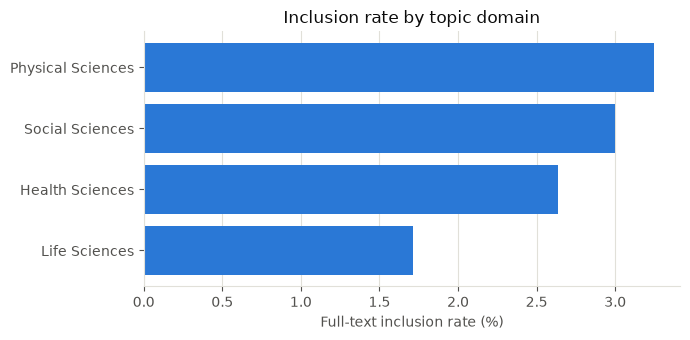

**Physical Sciences** records are included most often (3.2%), **Life Sciences** least often (1.7%) — a 1.9x spread.

In [9]:
inclusion_by_domain = (
    records.groupby("primary_topic_domain")["label_included"]
    .mean()
    .mul(100)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(inclusion_by_domain.index, inclusion_by_domain.values, color=BLUE)
ax.grid(axis="x")
ax.set_xlabel("Full-text inclusion rate (%)")
ax.set_title("Inclusion rate by topic domain")
fig.tight_layout()
plt.show()

display(
    Markdown(
        f"**{inclusion_by_domain.index[-1]}** records are included most often "
        f"({inclusion_by_domain.iloc[-1]:.1f}%), **{inclusion_by_domain.index[0]}** least often "
        f"({inclusion_by_domain.iloc[0]:.1f}%) — a "
        f"{inclusion_by_domain.iloc[-1] / inclusion_by_domain.iloc[0]:.1f}x spread."
    )
)

## Most common topics: overall vs. included

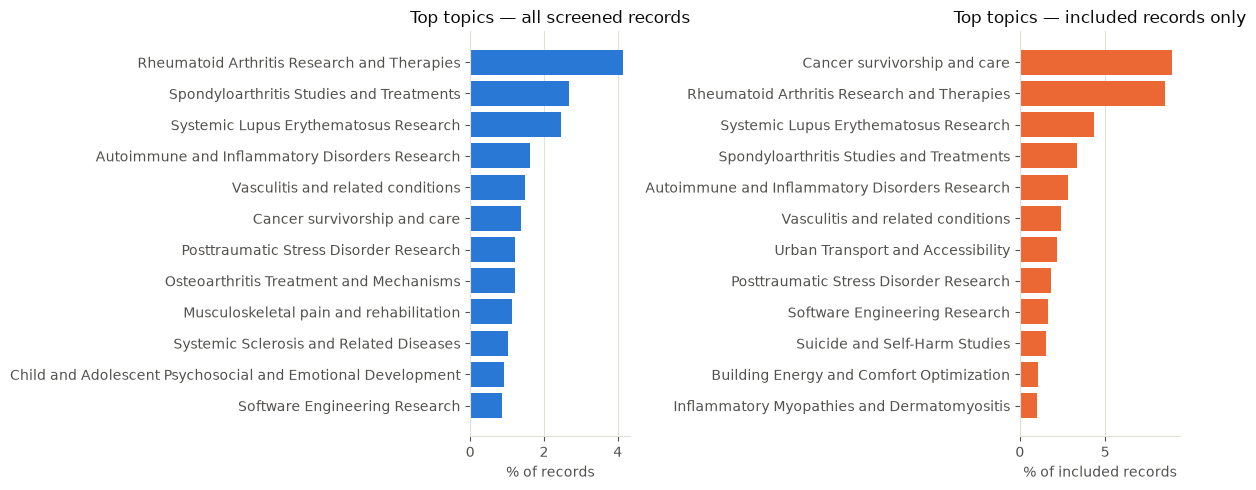

In [10]:
top_n = 12
overall_top = (
    records["primary_topic_name"].value_counts().head(top_n).div(n_records).mul(100)
)
included_top = (
    included["primary_topic_name"]
    .value_counts()
    .head(top_n)
    .div(len(included))
    .mul(100)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=False)

axes[0].barh(overall_top.index[::-1], overall_top.values[::-1], color=BLUE)
axes[0].set_title("Top topics — all screened records")
axes[0].set_xlabel("% of records")
axes[0].grid(axis="x")

axes[1].barh(included_top.index[::-1], included_top.values[::-1], color=ORANGE)
axes[1].set_title("Top topics — included records only")
axes[1].set_xlabel("% of included records")
axes[1].grid(axis="x")

fig.tight_layout()
plt.show()

In [11]:
shared_topics = set(overall_top.index) & set(included_top.index)

display(
    Markdown(
        f"{len(shared_topics)} of the top {top_n} topics appear on both lists. Topics that are common in the "
        "search corpus but don't crack the included-records list are candidates that get screened out often — "
        "and vice versa."
    )
)

8 of the top 12 topics appear on both lists. Topics that are common in the search corpus but don't crack the included-records list are candidates that get screened out often — and vice versa.

## Summary

In [12]:
display(
    Markdown(
        f"""
- **{has_topic:.1f}%** of {n_records:,} records carry a primary topic, across {records["primary_topic_domain"].nunique()} domains and {records["primary_topic_field"].nunique()} fields.
- **{top_dominant_field.index[0]}** is the dominant field for {top_dominant_field.iloc[0]} of {n_datasets} datasets.
- The dominant field of the full search matches the dominant field of the included subset for {drift_matches.mean() * 100:.0f}% of datasets.
- Inclusion rate by topic domain ranges from {inclusion_by_domain.iloc[0]:.1f}% ({inclusion_by_domain.index[0]}) to {inclusion_by_domain.iloc[-1]:.1f}% ({inclusion_by_domain.index[-1]}).
"""
    )
)


- **99.6%** of 168,969 records carry a primary topic, across 4 domains and 26 fields.
- **Medicine** is the dominant field for 56 of 114 datasets.
- The dominant field of the full search matches the dominant field of the included subset for 82% of datasets.
- Inclusion rate by topic domain ranges from 1.7% (Life Sciences) to 3.2% (Physical Sciences).
